# INAOE Thermogram Preprocessing Pipeline

## Overview
Complete preprocessing pipeline for INAOE thermogram images before model training.

### Dataset
- **Source:** INAOE Plantar Thermogram Database
- **Total Patients:** 167 (122 DM + 45 CT)
- **Total Images:** 334 (244 DM + 90 CT) - L-R feet only

### Processing Pipeline
1. Load INAOE images (L-R feet only)
2. Convert to grayscale (luminance-weighted)
3. Apply CLAHE enhancement (clip_limit=3.5)
4. Convert to 3-channel RGB
5. Resize to 224×224 pixels
6. Normalize to [0,1] range

### Output
- Directory: `E:\DFU\INAOE_Preprocessed`
- Format: PNG (0-255) + NPY (0-1 normalized)

## Section 1: Setup & Imports

In [1]:
import os
import sys
import warnings
import json
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import cv2

warnings.filterwarnings('ignore')

# Set random seeds
SEED = 42
np.random.seed(SEED)

# Configuration
CONFIG = {
    'inaoe_root': r'E:\DFU\Model\INAOE Dataset',
    'output_dir': r'E:\DFU\INAOE_Preprocessed',
    'img_size': (224, 224),
    'clahe_clip_limit': 3.5,
    'clahe_tile_grid': (8, 8),
    'results_dir': './results',
}

# Create output directories
os.makedirs(CONFIG['output_dir'], exist_ok=True)
os.makedirs(os.path.join(CONFIG['output_dir'], 'DM'), exist_ok=True)
os.makedirs(os.path.join(CONFIG['output_dir'], 'CT'), exist_ok=True)
os.makedirs(CONFIG['results_dir'], exist_ok=True)

# Initialize logging
log_file = os.path.join(CONFIG['results_dir'], f"preprocessing_log_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt")

def log_message(message: str, print_also: bool = True):
    """Log message to file and console"""
    with open(log_file, 'a') as f:
        f.write(f"[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] {message}\n")
    if print_also:
        print(message)

log_message("="*80)
log_message("INAOE THERMOGRAM PREPROCESSING PIPELINE")
log_message(f"Timestamp: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
log_message(f"Input: {CONFIG['inaoe_root']}")
log_message(f"Output: {CONFIG['output_dir']}")
log_message("="*80)

INAOE THERMOGRAM PREPROCESSING PIPELINE
Timestamp: 2026-04-22 13:58:35
Input: E:\DFU\Model\INAOE Dataset
Output: E:\DFU\INAOE_Preprocessed


## Section 2: Load INAOE Dataset (L-R Feet)

In [2]:
def load_inaoe_dataset(inaoe_root: str) -> list:
    """
    Load INAOE thermogram images (L-R feet only, skip Angiosoms).
    
    Returns:
        dataset: list of dicts with 'image_path', 'patient_id', 'foot', 'group'
    """
    dataset = []
    
    for group in ['DM', 'CT']:
        group_path = os.path.join(inaoe_root, group)
        
        if not os.path.exists(group_path):
            log_message(f"⚠ Warning: {group_path} not found")
            continue
        
        # Get all patient folders
        patient_folders = sorted([d for d in os.listdir(group_path) 
                                 if os.path.isdir(os.path.join(group_path, d))])
        
        for patient_id in patient_folders:
            patient_path = os.path.join(group_path, patient_id)
            
            # Look for L and R feet images
            for foot in ['L', 'R']:
                img_filename = f"{patient_id}_{foot}.png"
                img_path = os.path.join(patient_path, img_filename)
                
                if os.path.exists(img_path):
                    dataset.append({
                        'image_path': img_path,
                        'patient_id': patient_id,
                        'foot': foot,
                        'group': group,
                    })
    
    dm_count = sum(1 for d in dataset if d['group'] == 'DM')
    ct_count = sum(1 for d in dataset if d['group'] == 'CT')
    
    log_message(f"\nIAOE Dataset Loaded:")
    log_message(f"  - DM images: {dm_count}")
    log_message(f"  - CT images: {ct_count}")
    log_message(f"  - Total: {len(dataset)}")
    
    return dataset

# Load INAOE dataset
log_message(f"\nLoading INAOE dataset from: {CONFIG['inaoe_root']}")
inaoe_dataset = load_inaoe_dataset(CONFIG['inaoe_root'])


Loading INAOE dataset from: E:\DFU\Model\INAOE Dataset

IAOE Dataset Loaded:
  - DM images: 244
  - CT images: 90
  - Total: 334


## Section 3: Preprocessing Functions

In [3]:
def convert_to_grayscale(img_array: np.ndarray) -> np.ndarray:
    """Convert RGB image to grayscale using luminance formula."""
    if len(img_array.shape) == 3 and img_array.shape[2] == 3:
        gray = 0.299 * img_array[..., 0] + 0.587 * img_array[..., 1] + 0.114 * img_array[..., 2]
        return gray.astype(np.uint8)
    else:
        return img_array

def apply_clahe(image_gray: np.ndarray, clip_limit: float = 3.5, 
                tile_grid_size: tuple = (8, 8)) -> np.ndarray:
    """Apply Contrast Limited Adaptive Histogram Equalization."""
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    return clahe.apply(image_gray)

def convert_to_3channel_rgb(image_gray: np.ndarray) -> np.ndarray:
    """Convert grayscale to 3-channel RGB."""
    if len(image_gray.shape) == 2:
        return np.stack([image_gray, image_gray, image_gray], axis=-1)
    else:
        return image_gray

def resize_image(image: np.ndarray, target_size: tuple = (224, 224)) -> np.ndarray:
    """Resize image to target size."""
    pil_image = Image.fromarray(image)
    resized_pil = pil_image.resize((target_size[1], target_size[0]), Image.BILINEAR)
    return np.array(resized_pil)

def min_max_normalize(image: np.ndarray) -> np.ndarray:
    """Normalize image to [0, 1] range."""
    image_float = image.astype(np.float32)
    x_min = image_float.min()
    x_max = image_float.max()
    
    if x_max == x_min:
        return np.zeros_like(image_float)
    
    return (image_float - x_min) / (x_max - x_min)

log_message("\n✓ Preprocessing functions defined")


✓ Preprocessing functions defined


## Section 4: Single Image Preprocessing

In [4]:
def preprocess_single_inaoe_image(image_path: str, 
                                  clahe_clip_limit: float = 3.5,
                                  clahe_tile_grid: tuple = (8, 8),
                                  target_size: tuple = (224, 224),
                                  verbose: bool = False) -> np.ndarray:
    """
    Preprocess a single INAOE image through complete pipeline.
    
    Returns:
        processed_image: (H, W, 3) normalized RGB image in [0, 1]
    """
    try:
        # Load image
        img = Image.open(image_path).convert('RGB')
        img_array = np.array(img)
        
        # Convert to grayscale
        grayscale = convert_to_grayscale(img_array)
        
        # Apply CLAHE
        enhanced = apply_clahe(grayscale, clip_limit=clahe_clip_limit,
                              tile_grid_size=clahe_tile_grid)
        
        # Convert to RGB
        rgb = convert_to_3channel_rgb(enhanced)
        
        # Resize
        resized = resize_image(rgb, target_size=target_size)
        
        # Normalize
        normalized = min_max_normalize(resized)
        
        if verbose:
            log_message(f"  Normalized range: [{normalized.min():.4f}, {normalized.max():.4f}]")
        
        return normalized
    
    except Exception as e:
        log_message(f"✗ Error processing {image_path}: {str(e)}")
        return None

# Test on first image
if len(inaoe_dataset) > 0:
    test_item = inaoe_dataset[0]
    log_message(f"\nTesting preprocessing on: {test_item['patient_id']}_{test_item['foot']}")
    test_result = preprocess_single_inaoe_image(
        test_item['image_path'],
        clahe_clip_limit=CONFIG['clahe_clip_limit'],
        clahe_tile_grid=CONFIG['clahe_tile_grid'],
        target_size=CONFIG['img_size'],
        verbose=True
    )
    if test_result is not None:
        log_message(f"✓ Test successful. Shape: {test_result.shape}")


Testing preprocessing on: DM001_M_L
  Normalized range: [0.0000, 1.0000]
✓ Test successful. Shape: (224, 224, 3)


## Section 5: Batch Process All Images

In [5]:
def batch_preprocess_inaoe_dataset(dataset: list, output_root: str,
                                   clahe_clip_limit: float = 3.5,
                                   clahe_tile_grid: tuple = (8, 8),
                                   target_size: tuple = (224, 224),
                                   save_png: bool = True,
                                   save_npy: bool = True) -> dict:
    """
    Batch preprocess all INAOE images and save results.
    
    Returns:
        results: dict with processing statistics
    """
    results = {
        'total': len(dataset),
        'processed': 0,
        'failed': 0,
        'groups': {'DM': 0, 'CT': 0},
    }
    
    log_message("\n" + "="*80)
    log_message("BATCH PREPROCESSING INAOE DATASET")
    log_message("="*80)
    
    for idx, item in enumerate(dataset):
        image_path = item['image_path']
        patient_id = item['patient_id']
        foot = item['foot']
        group = item['group']
        
        # Process image
        processed = preprocess_single_inaoe_image(
            image_path,
            clahe_clip_limit=clahe_clip_limit,
            clahe_tile_grid=clahe_tile_grid,
            target_size=target_size,
            verbose=False
        )
        
        if processed is None:
            results['failed'] += 1
            continue
        
        # Create output directory
        group_output_dir = os.path.join(output_root, group)
        os.makedirs(group_output_dir, exist_ok=True)
        
        output_name = f"{patient_id}_{foot}"
        
        # Save as PNG
        if save_png:
            img_uint8 = (processed * 255).astype(np.uint8)
            img_pil = Image.fromarray(img_uint8)
            png_path = os.path.join(group_output_dir, f"{output_name}.png")
            img_pil.save(png_path)
        
        # Save as NPY
        if save_npy:
            npy_path = os.path.join(group_output_dir, f"{output_name}.npy")
            np.save(npy_path, processed)
        
        results['processed'] += 1
        results['groups'][group] += 1
        
        # Progress
        if (idx + 1) % 50 == 0:
            log_message(f"  Processed {idx + 1}/{len(dataset)} images...")
    
    # Summary
    log_message(f"\n{'='*80}")
    log_message(f"Processing Complete!")
    log_message(f"  - Total: {results['total']}")
    log_message(f"  - Processed: {results['processed']}")
    log_message(f"  - Failed: {results['failed']}")
    log_message(f"  - DM: {results['groups']['DM']}")
    log_message(f"  - CT: {results['groups']['CT']}")
    log_message(f"  - Output: {output_root}")
    log_message(f"{'='*80}\n")
    
    return results

# Run batch preprocessing
log_message("\nStarting batch preprocessing...")
preprocessing_results = batch_preprocess_inaoe_dataset(
    dataset=inaoe_dataset,
    output_root=CONFIG['output_dir'],
    clahe_clip_limit=CONFIG['clahe_clip_limit'],
    clahe_tile_grid=CONFIG['clahe_tile_grid'],
    target_size=CONFIG['img_size'],
    save_png=True,
    save_npy=True
)


Starting batch preprocessing...

BATCH PREPROCESSING INAOE DATASET
  Processed 50/334 images...
  Processed 100/334 images...
  Processed 150/334 images...
  Processed 200/334 images...
  Processed 250/334 images...
  Processed 300/334 images...

Processing Complete!
  - Total: 334
  - Processed: 334
  - Failed: 0
  - DM: 244
  - CT: 90
  - Output: E:\DFU\INAOE_Preprocessed



## Section 6: Load Preprocessed Dataset

In [6]:
def load_preprocessed_dataset_npy(output_root: str) -> tuple:
    """
    Load all preprocessed images from NPY files.
    
    Returns:
        images: (N, 224, 224, 3) array
        labels: (N,) array (0: CT, 1: DM)
        metadata: list of metadata dicts
    """
    images = []
    labels = []
    metadata = []
    
    for group_idx, group in enumerate(['CT', 'DM']):
        group_dir = os.path.join(output_root, group)
        
        if not os.path.exists(group_dir):
            continue
        
        npy_files = sorted([f for f in os.listdir(group_dir) if f.endswith('.npy')])
        
        for npy_file in npy_files:
            npy_path = os.path.join(group_dir, npy_file)
            img_array = np.load(npy_path)
            
            images.append(img_array)
            labels.append(group_idx)
            
            metadata.append({
                'filename': npy_file,
                'group': group,
                'label': group_idx,
                'shape': img_array.shape,
            })
    
    images = np.array(images, dtype=np.float32)
    labels = np.array(labels, dtype=np.int32)
    
    return images, labels, metadata

# Load preprocessed dataset
log_message("\nLoading preprocessed dataset...")
try:
    preprocessed_images, preprocessed_labels, image_metadata = load_preprocessed_dataset_npy(
        CONFIG['output_dir']
    )
    
    log_message(f"\n✓ Successfully loaded preprocessed dataset:")
    log_message(f"  - Total images: {len(preprocessed_images)}")
    log_message(f"  - Shape: {preprocessed_images.shape}")
    log_message(f"  - Data type: {preprocessed_images.dtype}")
    log_message(f"  - Value range: [{preprocessed_images.min():.4f}, {preprocessed_images.max():.4f}]")
    log_message(f"  - CT (label=0): {np.sum(preprocessed_labels == 0)}")
    log_message(f"  - DM (label=1): {np.sum(preprocessed_labels == 1)}")
    
except Exception as e:
    log_message(f"✗ Error loading preprocessed dataset: {str(e)}")


Loading preprocessed dataset...

✓ Successfully loaded preprocessed dataset:
  - Total images: 334
  - Shape: (334, 224, 224, 3)
  - Data type: float32
  - Value range: [0.0000, 1.0000]
  - CT (label=0): 90
  - DM (label=1): 244


## Section 7: Visualization - Before & After


Generating visualization...


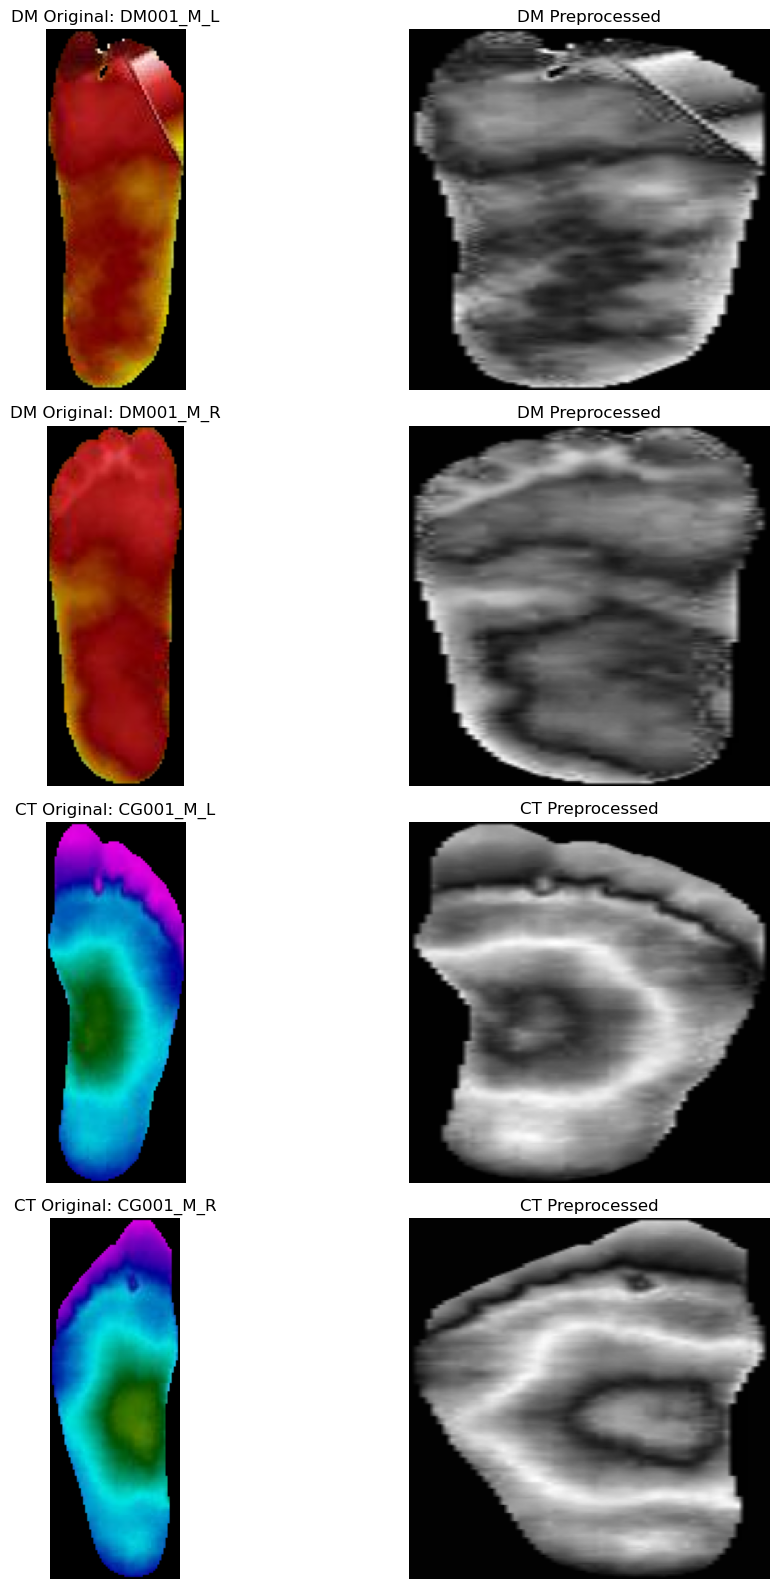

✓ Visualized 4 sample comparisons


In [7]:
def visualize_preprocessing_comparison(dataset: list, output_root: str, n_samples: int = 3):
    """
    Display side-by-side comparison of original vs preprocessed images.
    """
    dm_samples = [d for d in dataset if d['group'] == 'DM']
    ct_samples = [d for d in dataset if d['group'] == 'CT']
    
    total_rows = min(n_samples, len(dm_samples)) + min(n_samples, len(ct_samples))
    fig, axes = plt.subplots(total_rows, 2, figsize=(12, 4 * total_rows))
    
    if total_rows == 1:
        axes = axes.reshape(1, 2)
    
    plot_idx = 0
    
    for sample_list, group_label in [(dm_samples, 'DM'), (ct_samples, 'CT')]:
        for sample in sample_list[:n_samples]:
            original = np.array(Image.open(sample['image_path']).convert('RGB'))
            
            patient_id = sample['patient_id']
            foot = sample['foot']
            processed_path = os.path.join(output_root, sample['group'], 
                                         f"{patient_id}_{foot}.png")
            if os.path.exists(processed_path):
                processed = np.array(Image.open(processed_path))
                
                axes[plot_idx, 0].imshow(original)
                axes[plot_idx, 0].set_title(f"{group_label} Original: {patient_id}_{foot}")
                axes[plot_idx, 0].axis('off')
                
                axes[plot_idx, 1].imshow(processed, cmap='gray')
                axes[plot_idx, 1].set_title(f"{group_label} Preprocessed")
                axes[plot_idx, 1].axis('off')
                
                plot_idx += 1
    
    plt.tight_layout()
    plt.savefig(os.path.join(CONFIG['results_dir'], 'preprocessing_comparison.png'), dpi=150, bbox_inches='tight')
    plt.show()
    
    log_message(f"✓ Visualized {plot_idx} sample comparisons")

# Visualize samples
if len(inaoe_dataset) > 0:
    log_message("\nGenerating visualization...")
    visualize_preprocessing_comparison(inaoe_dataset, CONFIG['output_dir'], n_samples=2)

## Section 8: Summary & Export

In [8]:
# Save preprocessing statistics
stats = {
    'timestamp': datetime.now().isoformat(),
    'input_dataset': CONFIG['inaoe_root'],
    'output_directory': CONFIG['output_dir'],
    'total_images_processed': preprocessing_results['processed'],
    'total_images_failed': preprocessing_results['failed'],
    'dm_images': preprocessing_results['groups']['DM'],
    'ct_images': preprocessing_results['groups']['CT'],
    'preprocessing_config': {
        'clahe_clip_limit': CONFIG['clahe_clip_limit'],
        'clahe_tile_grid': CONFIG['clahe_tile_grid'],
        'target_size': CONFIG['img_size'],
    },
}

stats_file = os.path.join(CONFIG['results_dir'], 'preprocessing_stats.json')
with open(stats_file, 'w') as f:
    json.dump(stats, f, indent=2)

log_message(f"\n✓ Statistics saved to: {stats_file}")

# Final summary
log_message("\n" + "="*80)
log_message("PREPROCESSING COMPLETE")
log_message("="*80)
log_message(f"Input:  {CONFIG['inaoe_root']}")
log_message(f"Output: {CONFIG['output_dir']}")
log_message(f"Total processed: {preprocessing_results['processed']}")
log_message(f"  - DM: {preprocessing_results['groups']['DM']}")
log_message(f"  - CT: {preprocessing_results['groups']['CT']}")
log_message(f"Status: ✓ READY FOR TRAINING")
log_message("="*80)


✓ Statistics saved to: ./results\preprocessing_stats.json

PREPROCESSING COMPLETE
Input:  E:\DFU\Model\INAOE Dataset
Output: E:\DFU\INAOE_Preprocessed
Total processed: 334
  - DM: 244
  - CT: 90
Status: ✓ READY FOR TRAINING
